In [82]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import scipy.ndimage as ndimage

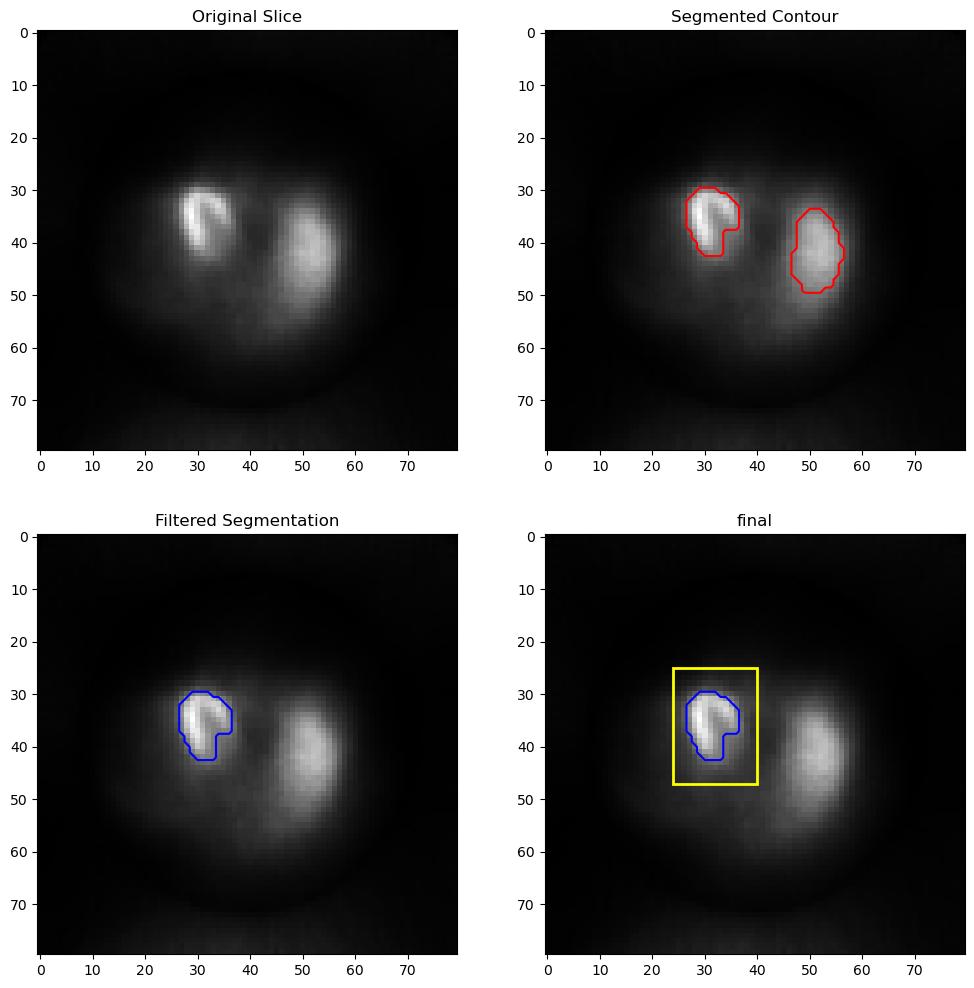

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import SimpleITK as sitk

# 读取 SPECT 数据 (NIfTI 格式)
def load_spect_data(filepath):
    image = sitk.ReadImage(filepath)
    data = sitk.GetArrayFromImage(image)[:, :, ::-1]  # 转换为 NumPy 数组，翻转轴以匹配方向
    voxel_size = image.GetSpacing()[::-1]  # 获取体素大小
    return data, voxel_size

def segment_left_ventricle(data, voxel_size):
    L = data.shape[2]
    upper_half = data[:, :, L//2:L]
    Cmax = np.max(upper_half)
    threshold = 5  # 固定阈值
    
    # 生成二值化掩膜
    binary_mask = data >= threshold
    
    # 连接成分分析
    labeled, num_features = ndimage.label(binary_mask)
    sizes = ndimage.sum(binary_mask, labeled, range(num_features + 1)) * np.linalg.norm(voxel_size)
    
    # 过滤小于 50ml 的区域
    min_size = 50
    mask_size_filter = sizes >= min_size
    filtered_mask = mask_size_filter[labeled]
    
    return filtered_mask

def visualize_segmentation(original, segmented, slice_idx=27):
    fig = plt.figure(figsize=(12, 12))
    # slice_idx = 40  # 选择固定的切片进行可视化
    
    ax = plt.subplot(221)
    plt.imshow(original[slice_idx], cmap='gray')
    ax.set_title("Original Slice")
    
    ax = plt.subplot(222)
    plt.imshow(original[slice_idx], cmap='gray')
    plt.contour(segmented[slice_idx], colors='r')
    ax.set_title("Segmented Contour")
    
    ax = plt.subplot(223)
    plt.imshow(original[slice_idx], cmap='gray')
    segmented[:, :, 40:] = 0
    # mask = 
    plt.contour(segmented[slice_idx], colors='b')
    ax.set_title("Filtered Segmentation")
    
    
    
    ax = plt.subplot(224)
    plt.imshow(original[slice_idx], cmap='gray')
    segmented[:, :, 40:] = 0
    # mask = 
    plt.contour(segmented[slice_idx], colors='b')
    ax.set_title("final")
    
    
    bounding_box = ndimage.find_objects(segmented[slice_idx])[0]
    height, width = bounding_box[0].stop - bounding_box[0].start, bounding_box[1].stop - bounding_box[1].start
    
    minr, maxr = bounding_box[0].start-5, bounding_box[0].stop+4
    minc, maxc = bounding_box[1].start-3, bounding_box[1].stop+3
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr, fill=False, edgecolor='yellow', linewidth=2)
    ax.add_patch(rect)
    
    plt.show()

# 读取真实数据
filepath = r"./tomo.nii.gz"
data, voxel_size = load_spect_data(filepath)
segmented = segment_left_ventricle(data, voxel_size)
visualize_segmentation(data, segmented, 27)
# visualize_segmentation(data, segmented, 28)
# visualize_segmentation(data, segmented, 32)